In [1]:
import kairo

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("../..") / ".env")

True

In [2]:
log = kairo.read_log("../../data/test.xes",
    case_id = "case:concept:id",
    activity = "concept:activity",
    timestamp = "time:completed",
    event_id = "event:uidd",
    start_timestamp = "begin:timestamp",
    resource = "org:actor",
    event_duration = "event:runtime_min")
log.head()

parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3699.77it/s]


,event:id,concept:name,start_timestamp,time:timestamp,event:duration_min,org:resource,case:concept:name,case:amount,case:region
0,e001,Create Order,2026-03-02 08:00:00+00:00,2026-03-02 08:12:00+00:00,12,Anna,C001,1200.5,EU
1,e002,Check Credit,2026-03-02 08:30:00+00:00,2026-03-02 08:50:00+00:00,20,Ben,C001,1200.5,EU
2,e003,Approve Order,2026-03-02 09:15:00+00:00,2026-03-02 09:25:00+00:00,10,Clara,C001,1200.5,EU
3,e004,Ship Goods,2026-03-03 10:00:00+00:00,2026-03-03 10:45:00+00:00,45,Dmitri,C001,1200.5,EU
4,e005,Create Order,2026-03-02 09:05:00+00:00,2026-03-02 09:20:00+00:00,15,Anna,C002,350.0,NA


In [3]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 3,
 'events': 12,
 'activities': 6,
 'resources': 5,
 'start': Timestamp('2026-03-02 08:12:00+0000', tz='UTC'),
 'end': Timestamp('2026-03-05 09:20:00+0000', tz='UTC'),
 'span_minutes': 4388.0,
 'tpt_days_min': 0.08194444444444444,
 'tpt_days_mean': 1.0800925925925926,
 'tpt_days_median': 1.10625,
 'tpt_days_max': 2.0520833333333335,
 'length_min': 3,
 'length_mean': 4.0,
 'length_median': 4.0,
 'length_max': 5,
 'activity_counts': concept:name
 Create Order     3
 Check Credit     3
 Approve Order    2
 Ship Goods       2
 Reject Order     1
 Send Invoice     1
 Name: count, dtype: int64,
 'resource_counts': org:resource
 Anna      3
 Ben       3
 Clara     3
 Dmitri    2
 Emre      1
 Name: count, dtype: int64}

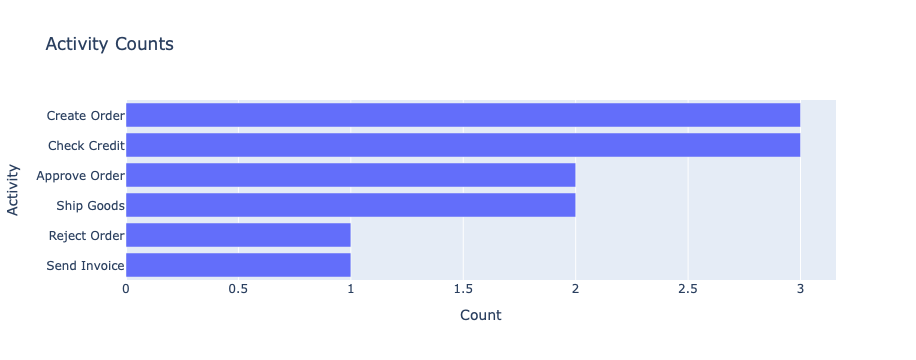

In [4]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [5]:
llm = kairo.LLMConnector(
    provider="anthropic",
    api_key=os.environ["ANTHROPIC_API_KEY"],
    model="claude-haiku-4-5-20251001"
)

response = llm.call(
    prompt="Very briefly analyze this process mining activity distribution. Do not use markdown format, just raw text",
    plots=[activity_plot],
)

response

Message(id='msg_011CfLjWtsL1WMv6MpjuARpP', container=None, content=[TextBlock(citations=None, text='The activity distribution shows a clear hierarchical pattern in process execution frequency. Create Order and Check Credit are the most frequent activities, each occurring approximately 3,000 times, representing the initial stages of the workflow. Approve Order and Ship Goods follow with roughly 2,000 occurrences each, indicating these are standard next steps. Reject Order and Send Invoice occur least frequently at around 1,000 times each. This distribution suggests a typical order-to-fulfillment process where most orders proceed through creation and credit checking, with fewer rejections. The relatively balanced frequencies between Approve Order and Ship Goods indicate good process flow, while the lower invoice and rejection counts suggest either high approval rates or that rejections and invoicing may occur in parallel or as exceptions rather than sequential steps.', type='text')], mod

In [6]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,act_freqs:Approve Order,act_freqs:Check Credit,act_freqs:Create Order,act_freqs:Reject Order,act_freqs:Send Invoice,act_freqs:Ship Goods,df_counts:Approve Order -> Ship Goods,df_counts:Check Credit -> Approve Order,df_counts:Check Credit -> Reject Order,df_counts:Create Order -> Check Credit,...,current_act:Create Order,current_act:Reject Order,current_act:Send Invoice,current_act:Ship Goods,past_acts_1:Approve Order,past_acts_1:Check Credit,past_acts_1:Create Order,past_acts_1:Reject Order,past_acts_1:Send Invoice,past_acts_1:Ship Goods
0,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.333333,0.333333,0.333333,0.000000,0.0,0.00,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.000000,0.333333,0.333333,0.333333,0.0,0.00,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,0.333333,0.333333,0.333333,0.000000,0.0,0.00,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.250000,0.250000,0.250000,0.000000,0.0,0.25,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [7]:
std_features = kairo.standardize(features, method="minmax")
std_features

,act_freqs:Approve Order,act_freqs:Check Credit,act_freqs:Create Order,act_freqs:Reject Order,act_freqs:Send Invoice,act_freqs:Ship Goods,df_counts:Approve Order -> Ship Goods,df_counts:Check Credit -> Approve Order,df_counts:Check Credit -> Reject Order,df_counts:Create Order -> Check Credit,...,current_act:Create Order,current_act:Reject Order,current_act:Send Invoice,current_act:Ship Goods,past_acts_1:Approve Order,past_acts_1:Check Credit,past_acts_1:Create Order,past_acts_1:Reject Order,past_acts_1:Send Invoice,past_acts_1:Ship Goods
0,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.00,0.666667,0.166667,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.00,0.666667,0.166667,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,1.00,0.666667,0.166667,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.75,0.500000,0.062500,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [8]:
compressed_features, stats = kairo.compute_pca(std_features, explained_var=0.99)
compressed_features

,pc_1,pc_2,pc_3,pc_4,pc_5
0,-1.476073,-1.156756,0.125798,-0.020526,-0.014442
1,-0.720085,1.072764,-0.817196,-0.212315,-0.154995
4,-1.452371,-1.145883,0.128177,0.001057,-0.001930
2,0.732297,0.486218,1.313696,-0.546888,-0.519547
5,-0.672680,1.094512,-0.812437,-0.169150,-0.129971
6,-0.334782,1.008466,0.947220,1.424064,1.110495
7,-1.490294,-1.163281,0.124370,-0.033475,-0.021949
8,-0.748527,1.059716,-0.820051,-0.238213,-0.170009
9,0.689633,0.466645,1.309413,-0.585736,-0.542068
3,1.835497,-0.539825,-0.447712,-0.433771,0.826922


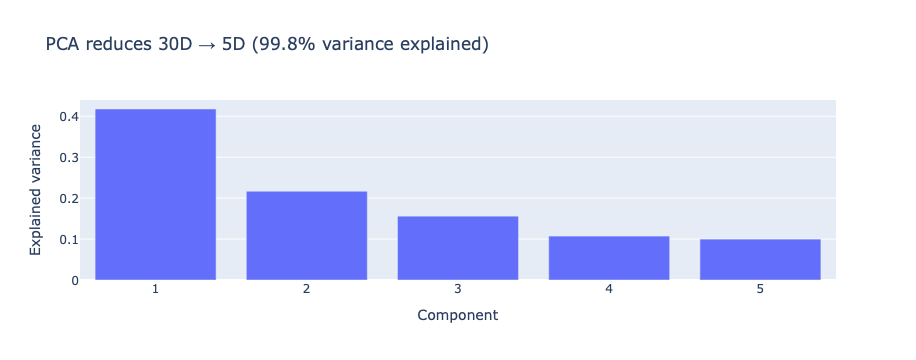

In [9]:
pca_plot = kairo.plot_pca_variances(stats)
pca_plot.show()

In [10]:
#clusters = kairo.compute_som(compressed_features, size=(3,3))
clusters = kairo.compute_som(features, size=(3,3))
clusters

,i,j
0,0,0
1,0,1
4,0,0
2,2,1
5,0,1
6,2,1
7,0,0
8,0,1
9,2,1
3,1,1


In [ ]:
plot